In [1]:
from rabtracks import *
sns.set_context("paper")
BASINS = ['NA', 'EP', 'NI', 'SI', 'SP', 'WP']

In [2]:
data = {b: xr.open_dataset("../RABTracks/RABTracks_"+b+".nc") for b in BASINS}

/tmp/ipykernel_738/2144106322.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  data = {b: xr.open_dataset("../RABTracks/RABTracks_"+b+".nc") for b in BASINS}
/tmp/ipykernel_738/2144106322.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  data = {b: xr.open_dataset("../RABTracks/RABTracks_"+b+".nc") for b in BASINS}


In [3]:
o = pd.DataFrame()
for b in BASINS:
    eib = data[b]
    eib_ib = eib.sel(source = "IBTrACS")
    eib_ib = clean(eib_ib.where(eib_ib.lon.notnull(),))
    eib_ib = clean(eib_ib.where(eib_ib.time.dt.year >= 1948,))
    for s in tqdm(eib.source.values):
        if s != "IBTrACS":
            eib_s = eib.sel(source = s)
            eib_s = clean(eib_s.where(eib_s.lon.notnull(),))
            o = pd.concat([o, huracanpy.assess.overlap(eib_ib, eib_s).assign(source = s, basin = b)])

100%|██████████| 9/9 [00:06<00:00,  1.43it/s]


In [4]:
o

,id_1,id_2,temp,dist,delta_start,delta_end,source,basin
0,1948143N17287,1948143N17287,25,104.990211,0.00,2.00,SyCLoPS-ERA5,NA
1,1948190N28271,1948190N28271,9,69.647820,0.00,-0.25,SyCLoPS-ERA5,NA
2,1948239N20299,1948239N20299,22,150.828888,4.50,2.00,SyCLoPS-ERA5,NA
3,1948246N24265,1948246N24265,21,89.094025,-1.50,0.25,SyCLoPS-ERA5,NA
4,1948248N14340,1948248N14340,28,159.886154,0.25,2.25,SyCLoPS-ERA5,NA
...,...,...,...,...,...,...,...,...
1508,2024307N06143,2024307N06143,45,40.106178,-5.25,2.25,TRACK-NCEP,WP
1509,2024312N14145,2024312N14145,30,64.190941,-3.75,-1.00,TRACK-NCEP,WP
1510,2024313N10169,2024313N10169,50,55.032593,-9.00,0.75,TRACK-NCEP,WP
1511,2024314N07151,2024314N07151,31,50.569077,-3.25,0.25,TRACK-NCEP,WP


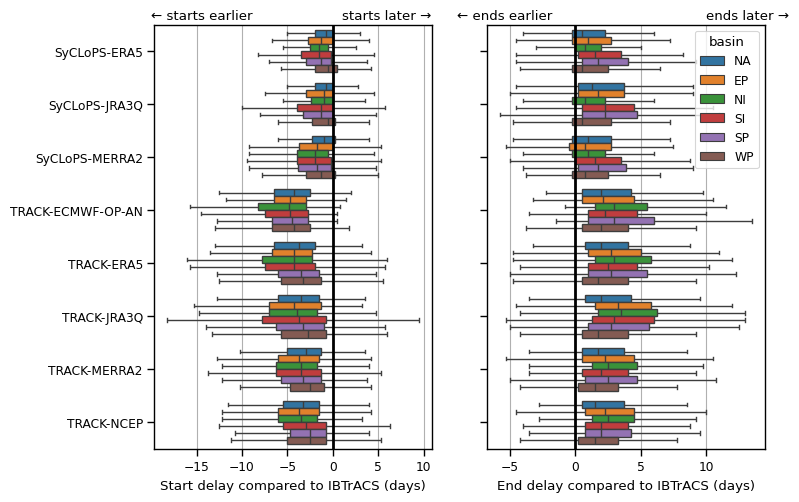

In [5]:
fig, axs = plt.subplots(1,2, figsize = cm2inch((20,14)), sharey = True)
sns.boxplot(data = o, x = "delta_start", y = "source", hue = "basin",  ax = axs[0], showfliers = False, legend = False)
sns.boxplot(data = o, x = "delta_end", y = "source",hue = "basin", ax = axs[1], showfliers = False)
for i in range(2):
    axs[i].grid(axis = 'x')
    axs[i].axvline(x = 0, linewidth = 2, color = 'k')
#fig.suptitle("Time difference between the sources track's onset & offset, compared to IBTrACS")
axs[0].text(-20, -0.6, "← starts earlier")
axs[0].text(1, -0.6, "starts later →")
axs[1].text(-9, -0.6, "← ends earlier")
axs[1].text(10, -0.6, "ends later →")
axs[0].set_xlabel("Start delay compared to IBTrACS (days)")
axs[0].set_ylabel("")
axs[1].set_xlabel("End delay compared to IBTrACS (days)")

plt.savefig("overlap.png", bbox_inches = "tight")
plt.savefig("overlap.pdf", bbox_inches = "tight")

Text(0.5, 0, 'End delay compared to IBTrACS (days)')

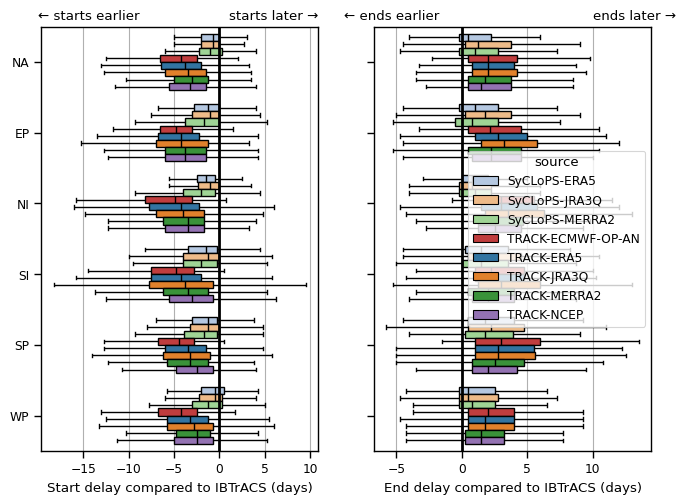

In [6]:
fig, axs = plt.subplots(1,2, figsize = cm2inch((20,14)), sharey = True)
sns.boxplot(data = o, x = "delta_start", hue = "source", y = "basin", palette= PALETTE, ax = axs[0], showfliers = False, legend = False)
sns.boxplot(data = o, x = "delta_end", hue = "source",y = "basin", palette= PALETTE, ax = axs[1], showfliers = False)
for i in range(2):
    axs[i].grid(axis = 'x')
    axs[i].axvline(x = 0, linewidth = 2, color = 'k')
#fig.suptitle("Time difference between the sources track's onset & offset, compared to IBTrACS")
axs[0].text(-20, -0.6, "← starts earlier")
axs[0].text(1, -0.6, "starts later →")
axs[1].text(-9, -0.6, "← ends earlier")
axs[1].text(10, -0.6, "ends later →")
axs[0].set_xlabel("Start delay compared to IBTrACS (days)")
axs[0].set_ylabel("")
axs[1].set_xlabel("End delay compared to IBTrACS (days)")